# Trash Fires and Weather in New York City (2016–2022)

## Research Question

How do weather conditions (temperature, precipitation, wind speed, and cloud cover as a proxy for humidity) relate to daily trash fire incidents in New York City between 2016 and 2022?

## Data

- **FDNY trash fire incidents**  
  - Source: FDNY “Incidents Responded to by Fire Companies” (filtered to incident type *118 - Trash or rubbish fire, contained*).
  - Fields used: incident datetime, borough, incident duration, action taken, fire spread, etc.

- **NYC weather data (2016–2022)**  
  - Source: NYC_Weather_2016_2022.csv  
  - Hourly variables: time, temperature (°C), precipitation (mm), rain (mm), cloud cover (%), wind speed (km/h), wind direction.

We aggregate both datasets to the **daily level** (per calendar date), then study:

1. Temporal and spatial patterns of trash fires (overall and by borough).
2. How daily weather conditions correlate with daily trash fire counts.
3. Whether simple regression models can explain or predict changes in trash fire risk.

This notebook follows the course methodology:
- Data cleaning  
- Descriptive analysis & exploratory data analysis (EDA)  
- Data distribution checks  
- Hypothesis testing  
- Regression modelling  
- Interpretation and conclusion


In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
import scipy.stats as stats

# For regression later
import statsmodels.api as sm

# Nice plots
plt.style.use("seaborn-v0_8")
sns.set_context("talk")


In [7]:
# ---- Upload both files manually in Colab:
# 1) Incidents_Responded_to_by_Fire_Companies_20251202 (1).csv
# 2) NYC_Weather_2016_2022.csv

uploaded = files.upload()
uploaded.keys()


Saving Incidents_Responded_to_by_Fire_Companies_20251202 (1).csv to Incidents_Responded_to_by_Fire_Companies_20251202 (1) (1).csv
Saving NYC_Weather_2016_2022.csv to NYC_Weather_2016_2022 (1).csv


dict_keys(['Incidents_Responded_to_by_Fire_Companies_20251202 (1) (1).csv', 'NYC_Weather_2016_2022 (1).csv'])

In [8]:
# Identify the uploaded files correctly
fire_fname = [f for f in uploaded.keys() if 'Incidents' in f][0]
weather_fname = [f for f in uploaded.keys() if 'Weather' in f][0]

print("Fire file:", fire_fname)
print("Weather file:", weather_fname)

# Read both directly as CSVs
fire_df = pd.read_csv(io.BytesIO(uploaded[fire_fname]))
print("Fire data shape:", fire_df.shape)

weather_df = pd.read_csv(io.BytesIO(uploaded[weather_fname]))
print("Weather data shape:", weather_df.shape)


Fire file: Incidents_Responded_to_by_Fire_Companies_20251202 (1) (1).csv
Weather file: NYC_Weather_2016_2022 (1).csv
Fire data shape: (13041, 24)
Weather data shape: (59760, 10)


In [9]:
weather_df.columns.tolist()
weather_df.head()


,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
0,2016-01-01T00:00,7.6,0.0,0.0,69.0,53.0,0.0,72.0,10.0,296.0
1,2016-01-01T01:00,7.5,0.0,0.0,20.0,4.0,0.0,56.0,9.8,287.0
2,2016-01-01T02:00,7.1,0.0,0.0,32.0,3.0,0.0,99.0,9.7,285.0
3,2016-01-01T03:00,6.6,0.0,0.0,35.0,5.0,0.0,100.0,9.2,281.0
4,2016-01-01T04:00,6.3,0.0,0.0,34.0,4.0,0.0,100.0,9.1,279.0


Clean Dates, Years, Boroughs, Weather Columns

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")
sns.set_context("talk")

# =========================
# FIRE DATA CLEANING
# =========================

# 1. Keep only trash/rubbish fires (should already be, but enforce it)
trash_mask = fire_df['INCIDENT_TYPE_DESC'].str.contains(
    'Trash or rubbish fire', case=False, na=False
)
fire_df = fire_df[trash_mask].copy()

print("After filtering to trash fires:", fire_df.shape)

# 2. Parse incident datetime (format has AM/PM)
fire_df['INCIDENT_DATETIME'] = pd.to_datetime(
    fire_df['INCIDENT_DATE_TIME'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# 3. Create Date and Year
fire_df['Date'] = fire_df['INCIDENT_DATETIME'].dt.date
fire_df['Year'] = fire_df['INCIDENT_DATETIME'].dt.year

# 4. Restrict to 2016–2022
fire_df = fire_df[(fire_df['Year'] >= 2016) & (fire_df['Year'] <= 2022)].copy()

print("Years in fire data:", sorted(fire_df['Year'].dropna().unique()))

# 5. Clean borough labels: "4 - Brooklyn" -> "BROOKLYN"
borough_map = {
    '1 - Manhattan': 'MANHATTAN',
    '2 - Bronx': 'BRONX',
    '3 - Staten Island': 'STATEN ISLAND',
    '4 - Brooklyn': 'BROOKLYN',
    '5 - Queens': 'QUEENS'
}
fire_df['BOROUGH_CLEAN'] = fire_df['BOROUGH_DESC'].map(borough_map)

print("Unique BOROUGH_CLEAN:", fire_df['BOROUGH_CLEAN'].unique())

# =========================
# WEATHER DATA CLEANING
# =========================

# 1. Parse time
weather_df['time'] = pd.to_datetime(weather_df['time'], errors='coerce')

# 2. Date & Year
weather_df['Date'] = weather_df['time'].dt.date
weather_df['Year'] = weather_df['time'].dt.year

# 3. Restrict to 2016–2022 just in case
weather_df = weather_df[(weather_df['Year'] >= 2016) & (weather_df['Year'] <= 2022)].copy()

# 4. Keep only relevant columns
weather_df = weather_df[[
    'time',
    'Date',
    'Year',
    'temperature_2m (°C)',
    'precipitation (mm)',
    'rain (mm)',
    'cloudcover (%)',
    'windspeed_10m (km/h)'
]].copy()

weather_df.rename(columns={
    'temperature_2m (°C)': 'temp_C',
    'precipitation (mm)': 'precip_mm',
    'rain (mm)': 'rain_mm',
    'cloudcover (%)': 'cloud_pct',
    'windspeed_10m (km/h)': 'wind_kmh'
}, inplace=True)

print("Weather columns after cleaning:", weather_df.columns.tolist())


After filtering to trash fires: (13041, 24)
Years in fire data: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
Unique BOROUGH_CLEAN: ['BROOKLYN' 'MANHATTAN' 'BRONX' 'QUEENS' 'STATEN ISLAND']
Weather columns after cleaning: ['time', 'Date', 'Year', 'temp_C', 'precip_mm', 'rain_mm', 'cloud_pct', 'wind_kmh']


Aggregate to Daily Fire Counts + Daily Weather

In [11]:
# =========================
# DAILY FIRE COUNTS
# =========================

# Daily total trash fires across NYC
daily_fire_total = (
    fire_df
    .groupby('Date')
    .size()
    .reset_index(name='trash_fire_count')
)

# Daily trash fires per borough
daily_fire_borough = (
    fire_df
    .groupby(['Date', 'BOROUGH_CLEAN'])
    .size()
    .reset_index(name='trash_fire_count')
)

print("daily_fire_total head:")
print(daily_fire_total.head())

print("\ndaily_fire_borough head:")
print(daily_fire_borough.head())

# =========================
# DAILY WEATHER AGGREGATION
# =========================

daily_weather = (
    weather_df
    .groupby('Date')
    .agg(
        mean_temp=('temp_C', 'mean'),
        total_precip=('precip_mm', 'sum'),
        total_rain=('rain_mm', 'sum'),
        mean_wind=('wind_kmh', 'mean'),
        mean_cloud=('cloud_pct', 'mean')
    )
    .reset_index()
)

print("\ndaily_weather head:")
print(daily_weather.head())


daily_fire_total head:
         Date  trash_fire_count
0  2016-01-01                10
1  2016-01-02                 5
2  2016-01-03                 4
3  2016-01-04                10
4  2016-01-05                 6

daily_fire_borough head:
         Date  BOROUGH_CLEAN  trash_fire_count
0  2016-01-01          BRONX                 2
1  2016-01-01       BROOKLYN                 1
2  2016-01-01      MANHATTAN                 2
3  2016-01-01         QUEENS                 4
4  2016-01-01  STATEN ISLAND                 1

daily_weather head:
         Date  mean_temp  total_precip  total_rain  mean_wind  mean_cloud
0  2016-01-01   5.408333           0.0         0.0  12.475000   57.291667
1  2016-01-02   2.387500           0.0         0.0  13.375000   10.250000
2  2016-01-03   3.012500           0.0         0.0  12.750000   10.291667
3  2016-01-04   0.100000           0.0         0.0  16.854167   14.750000
4  2016-01-05  -6.775000           0.0         0.0  17.645833    0.666667


In [ ]:
Merge Daily Fire + Weather → Core Analysis Table

In [12]:
# Merge on Date (inner: keep days present in both)
df_daily = pd.merge(
    daily_fire_total,
    daily_weather,
    on='Date',
    how='inner'
)

print("Merged daily shape:", df_daily.shape)
print(df_daily.head())

print("\nSummary stats of merged variables:")
print(df_daily.describe())


Merged daily shape: (2461, 7)
         Date  trash_fire_count  mean_temp  total_precip  total_rain  \
0  2016-01-01                10   5.408333           0.0         0.0   
1  2016-01-02                 5   2.387500           0.0         0.0   
2  2016-01-03                 4   3.012500           0.0         0.0   
3  2016-01-04                10   0.100000           0.0         0.0   
4  2016-01-05                 6  -6.775000           0.0         0.0   

   mean_wind  mean_cloud  
0  12.475000   57.291667  
1  13.375000   10.250000  
2  12.750000   10.291667  
3  16.854167   14.750000  
4  17.645833    0.666667  

Summary stats of merged variables:
       trash_fire_count    mean_temp  total_precip   total_rain    mean_wind  \
count       2461.000000  2454.000000   2461.000000  2461.000000  2454.000000   
mean           5.299065    13.210045      3.166355     2.917188    11.377611   
std            2.709955     9.480796      6.969124     6.648120     4.538241   
min            1.00

Basic Descriptive Plots (for “Descriptive analysis & EDA” slide)

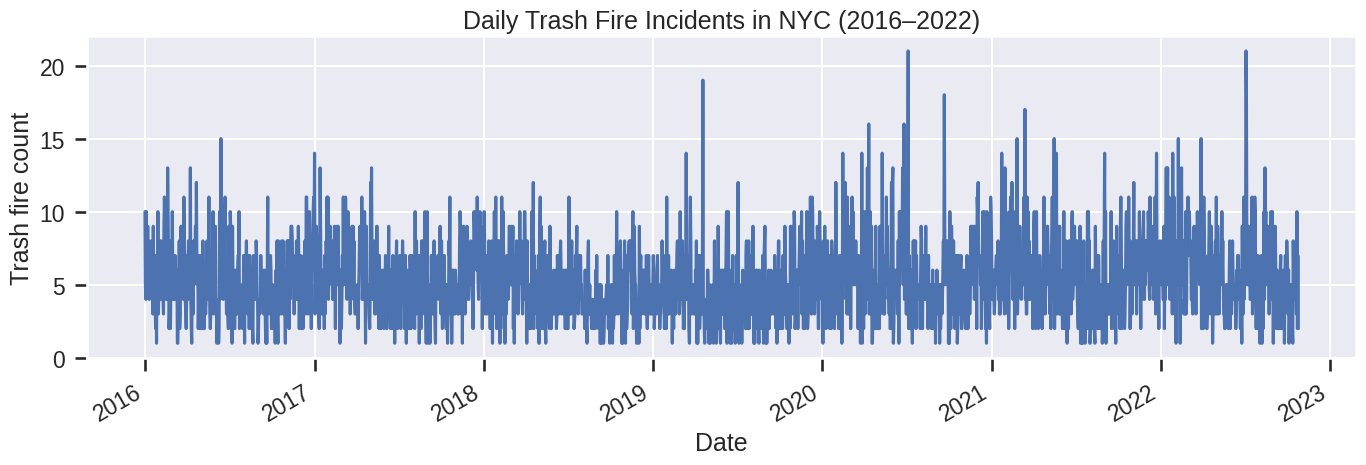

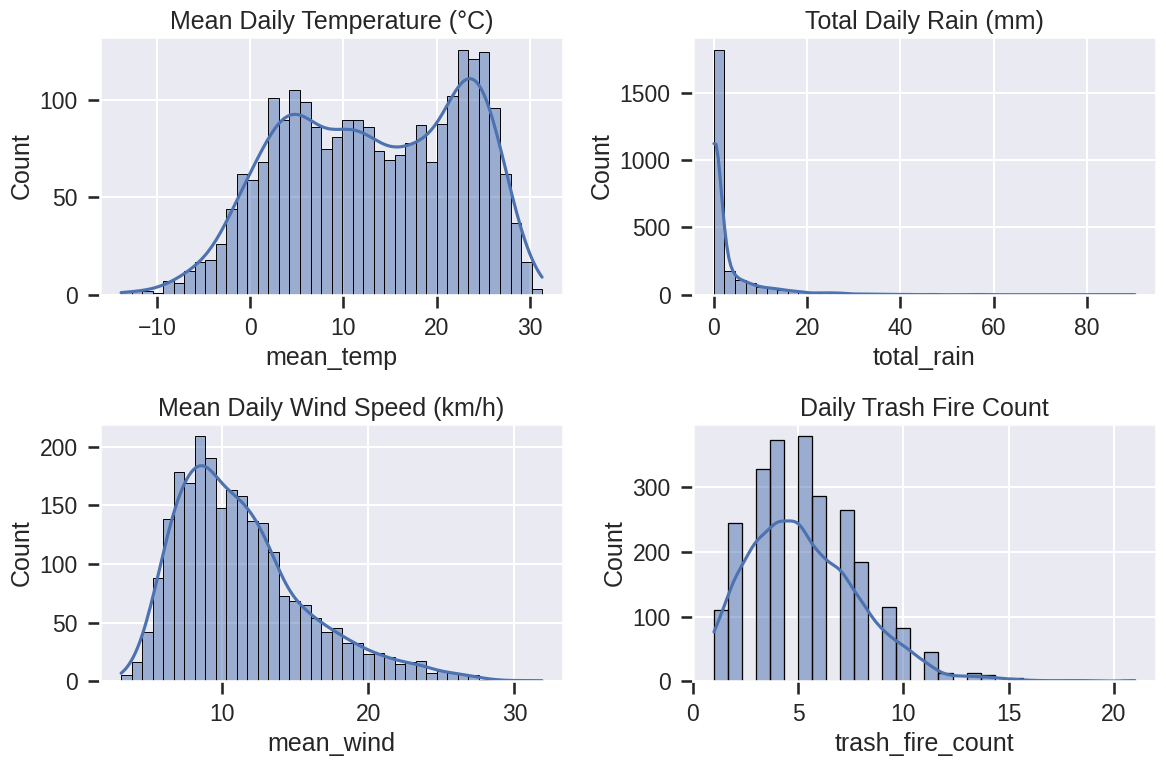

In [13]:
# Convert Date to datetime index for plotting
df_daily_plot = df_daily.copy()
df_daily_plot['Date'] = pd.to_datetime(df_daily_plot['Date'])
df_daily_plot = df_daily_plot.set_index('Date').sort_index()

# 1. Time series of daily trash fires
plt.figure(figsize=(14,5))
df_daily_plot['trash_fire_count'].plot()
plt.title("Daily Trash Fire Incidents in NYC (2016–2022)")
plt.ylabel("Trash fire count")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

# 2. Histograms of weather variables
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(df_daily['mean_temp'], bins=40, kde=True, ax=axes[0,0])
axes[0,0].set_title("Mean Daily Temperature (°C)")

sns.histplot(df_daily['total_rain'], bins=40, kde=True, ax=axes[0,1])
axes[0,1].set_title("Total Daily Rain (mm)")

sns.histplot(df_daily['mean_wind'], bins=40, kde=True, ax=axes[1,0])
axes[1,0].set_title("Mean Daily Wind Speed (km/h)")

sns.histplot(df_daily['trash_fire_count'], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title("Daily Trash Fire Count")

plt.tight_layout()
plt.show()


QQ Plots / Distribution Check (for “Data distribution” step)

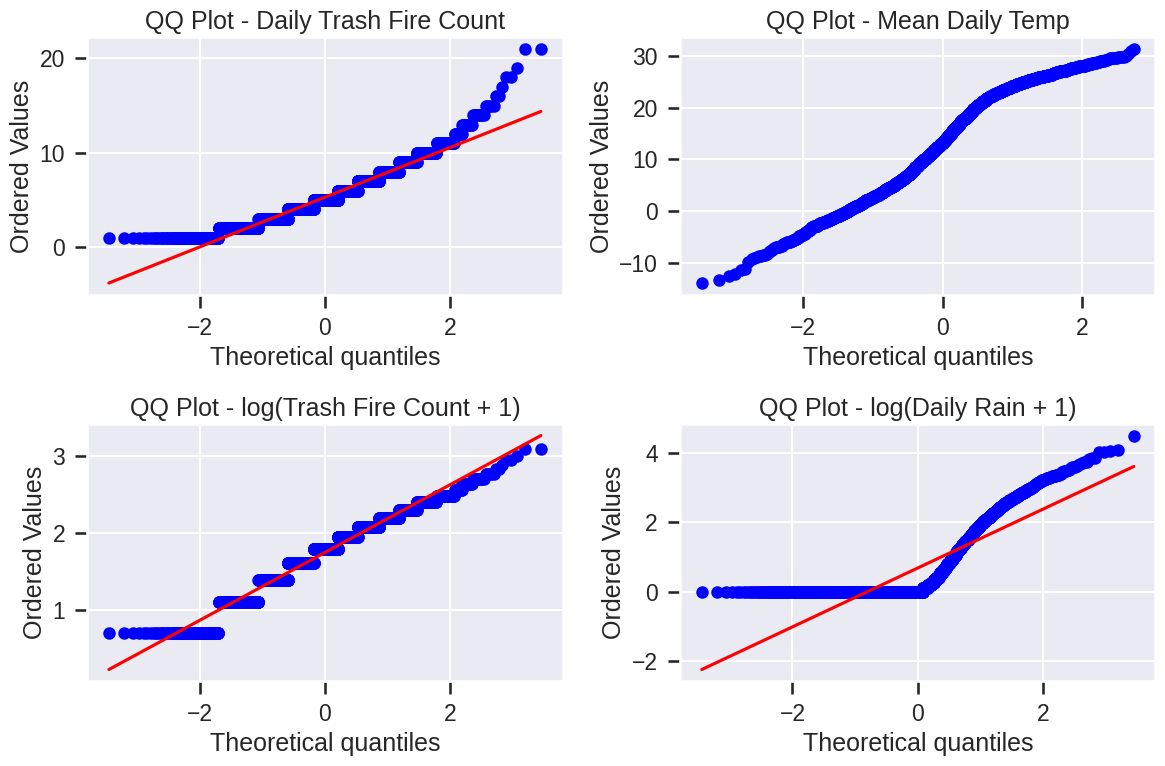

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Trash fire count
stats.probplot(df_daily['trash_fire_count'], dist="norm", plot=axes[0,0])
axes[0,0].set_title("QQ Plot - Daily Trash Fire Count")

# Mean temp
stats.probplot(df_daily['mean_temp'], dist="norm", plot=axes[0,1])
axes[0,1].set_title("QQ Plot - Mean Daily Temp")

# Log of trash_fire_count + 1 (to reduce skew)
stats.probplot(np.log1p(df_daily['trash_fire_count']), dist="norm", plot=axes[1,0])
axes[1,0].set_title("QQ Plot - log(Trash Fire Count + 1)")

# Log of rain + 1
stats.probplot(np.log1p(df_daily['total_rain']), dist="norm", plot=axes[1,1])
axes[1,1].set_title("QQ Plot - log(Daily Rain + 1)")

plt.tight_layout()
plt.show()


Hypothesis 1:

H0: Weather has no impact on trash fire counts,  
H1: Weather influences trash fire counts

In [ ]:
Correlation: Temperature vs Trash Fire Count

Correlation (Temp vs Fires): -0.19104384977434363
p-value: 1.3332124526521388e-21


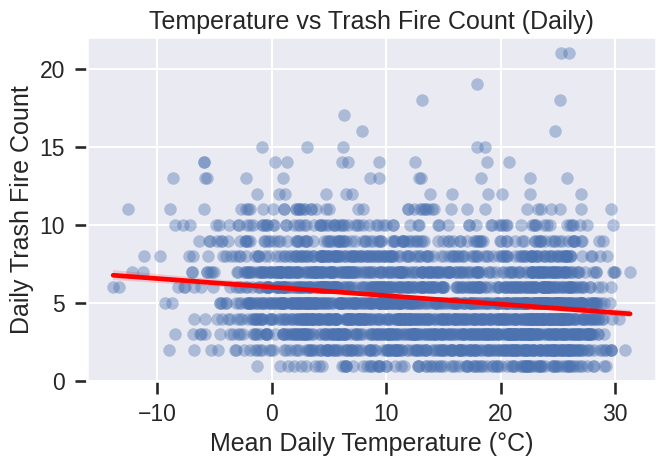

In [18]:
# TEMP vs TRASH FIRE CORRELATION

# Drop NA rows for valid correlation
corr_temp_df = df_daily[['mean_temp','trash_fire_count']].dropna()

# Pearson correlation
corr_temp, p_temp = stats.pearsonr(
    corr_temp_df['mean_temp'], corr_temp_df['trash_fire_count']
)

print("Correlation (Temp vs Fires):", corr_temp)
print("p-value:", p_temp)

# Plot: Scatter + Regression Line
plt.figure(figsize=(7,5))
sns.regplot(
    x='mean_temp', y='trash_fire_count',
    data=corr_temp_df,
    scatter_kws={'alpha':0.4}, line_kws={'color':'red'}
)
plt.title("Temperature vs Trash Fire Count (Daily)")
plt.xlabel("Mean Daily Temperature (°C)")
plt.ylabel("Daily Trash Fire Count")
plt.tight_layout()
plt.show()


Variance equal: True
T-test p-value: 4.341938483631845e-19


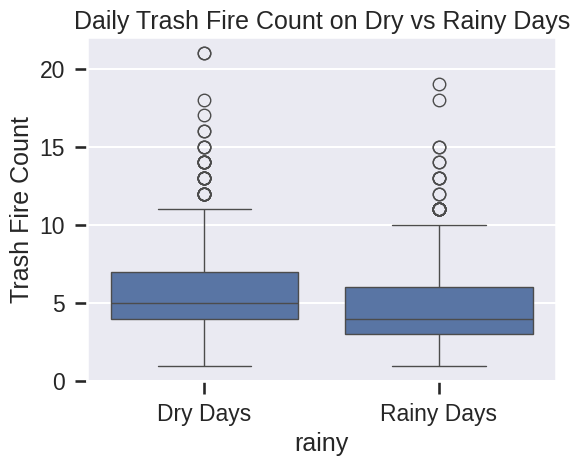

In [19]:
# DRY vs RAINY DAYS TEST

df_daily['rainy'] = (df_daily['total_rain'] > 0).astype(int)

dry = df_daily[df_daily['rainy']==0]['trash_fire_count']
rain = df_daily[df_daily['rainy']==1]['trash_fire_count']

# Check variance equality
levene_stat, levene_p = stats.levene(dry, rain)
equal_var = levene_p > 0.05
print("Variance equal:", equal_var)

# Welch or standard t-test
t_stat, t_p = stats.ttest_ind(dry, rain, equal_var=equal_var)
print("T-test p-value:", t_p)

# Visualization
plt.figure(figsize=(6,5))
sns.boxplot(x='rainy', y='trash_fire_count', data=df_daily)
plt.xticks([0,1], ['Dry Days', 'Rainy Days'])
plt.title("Daily Trash Fire Count on Dry vs Rainy Days")
plt.ylabel("Trash Fire Count")
plt.tight_layout()
plt.show()


Correlation (Wind vs Fires): 0.10986817599837143
p-value: 4.859209196805543e-08


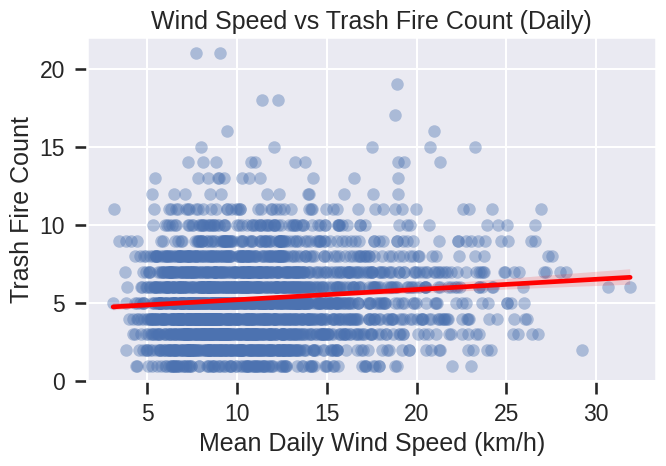

In [20]:
corr_wind_df = df_daily[['mean_wind','trash_fire_count']].dropna()

corr_wind, p_wind = stats.pearsonr(
    corr_wind_df['mean_wind'], corr_wind_df['trash_fire_count']
)

print("Correlation (Wind vs Fires):", corr_wind)
print("p-value:", p_wind)

# Scatterplot
plt.figure(figsize=(7,5))
sns.regplot(
    x='mean_wind', y='trash_fire_count',
    data=corr_wind_df, scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)
plt.title("Wind Speed vs Trash Fire Count (Daily)")
plt.xlabel("Mean Daily Wind Speed (km/h)")
plt.ylabel("Trash Fire Count")
plt.tight_layout()
plt.show()


ANOVA F-statistic: 150.56201334570278
p-value: 8.505827535445599e-124


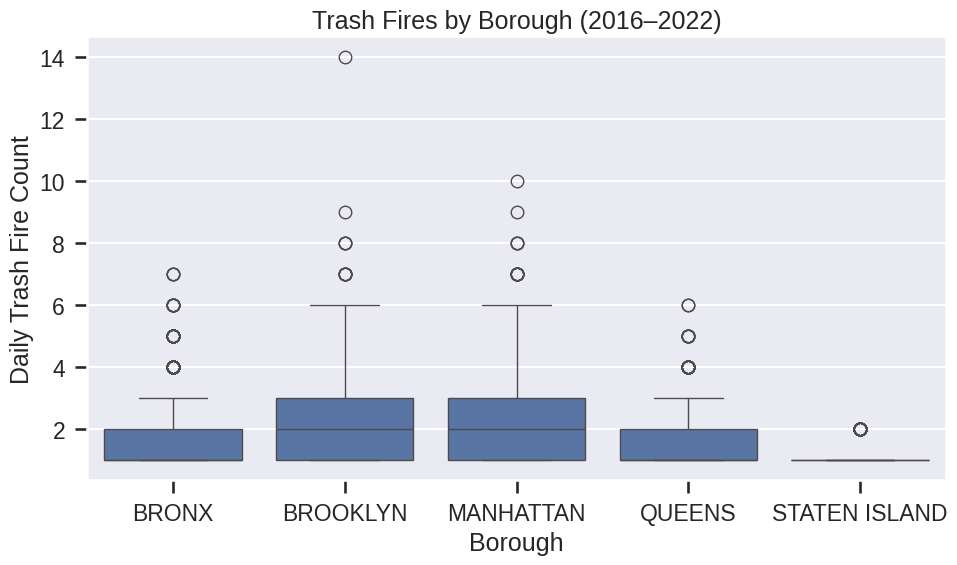

In [21]:
# Merge borough daily fire + weather data
df_boro = pd.merge(daily_fire_borough, daily_weather, on='Date', how='inner')

# Extract borough list
boroughs = sorted(df_boro['BOROUGH_CLEAN'].unique())

# ANOVA groups
groups = [df_boro[df_boro['BOROUGH_CLEAN'] == b]['trash_fire_count'] for b in boroughs]

f_stat, p_anova = stats.f_oneway(*groups)
print("ANOVA F-statistic:", f_stat)
print("p-value:", p_anova)

# Visualization
plt.figure(figsize=(10,6))
sns.boxplot(
    x='BOROUGH_CLEAN',
    y='trash_fire_count',
    data=df_boro,
    order=boroughs
)
plt.title("Trash Fires by Borough (2016–2022)")
plt.xlabel("Borough")
plt.ylabel("Daily Trash Fire Count")
plt.tight_layout()
plt.show()


In [22]:
import statsmodels.api as sm

# Drop rows with missing data
reg_data = df_daily.dropna()

X = reg_data[['mean_temp', 'total_precip', 'mean_wind', 'mean_cloud']]
y = reg_data['trash_fire_count']

# Add constant for intercept
X = sm.add_constant(X)

# Fit model
model_raw = sm.OLS(y, X).fit()

print(model_raw.summary())


                            OLS Regression Results                            
Dep. Variable:       trash_fire_count   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     48.56
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.34e-39
Time:                        02:42:55   Log-Likelihood:                -5834.2
No. Observations:                2454   AIC:                         1.168e+04
Df Residuals:                    2449   BIC:                         1.171e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.1520      0.209     29.404   

In [23]:
# Log-transformed model
reg_data['log_fire'] = np.log1p(reg_data['trash_fire_count'])
reg_data['log_rain'] = np.log1p(reg_data['total_rain'])

X2 = reg_data[['mean_temp', 'log_rain', 'mean_wind', 'mean_cloud']]
y2 = reg_data['log_fire']

X2 = sm.add_constant(X2)
model_log = sm.OLS(y2, X2).fit()

print(model_log.summary())


                            OLS Regression Results                            
Dep. Variable:               log_fire   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     56.00
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.97e-45
Time:                        02:43:38   Log-Likelihood:                -1400.4
No. Observations:                2454   AIC:                             2811.
Df Residuals:                    2449   BIC:                             2840.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8677      0.035     54.127      0.0

/tmp/ipython-input-2490841594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['log_fire'] = np.log1p(reg_data['trash_fire_count'])
/tmp/ipython-input-2490841594.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['log_rain'] = np.log1p(reg_data['total_rain'])


/tmp/ipython-input-4000388952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['pred_log_model'] = model_log.predict(X2)


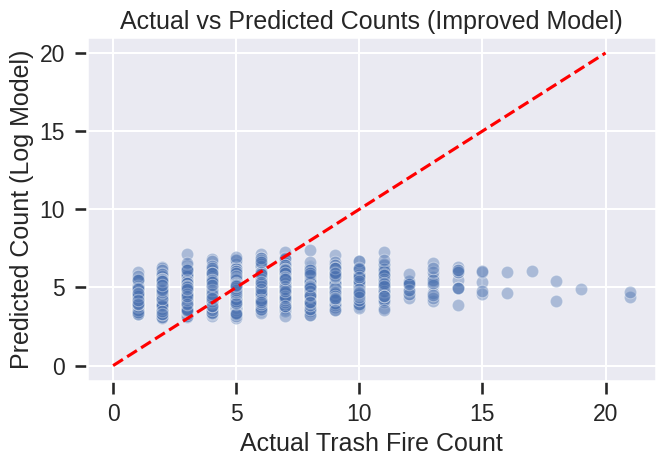

In [24]:
# Compare actual vs predicted (log model)
reg_data['pred_log_model'] = model_log.predict(X2)

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=reg_data['trash_fire_count'],
    y=np.expm1(reg_data['pred_log_model']),
    alpha=0.4
)
plt.xlabel("Actual Trash Fire Count")
plt.ylabel("Predicted Count (Log Model)")
plt.title("Actual vs Predicted Counts (Improved Model)")
plt.plot([0,20], [0,20], color='red', linestyle='--')
plt.tight_layout()
plt.show()


/tmp/ipython-input-787948434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg_data['predicted_count'] = np.expm1(model_log.predict(X2))


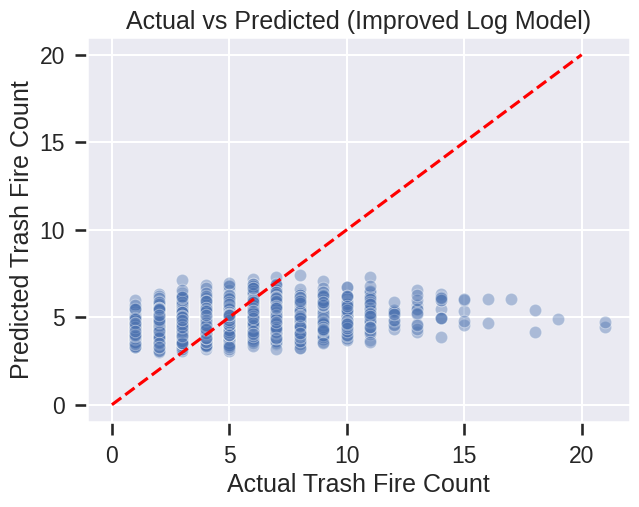

In [25]:
reg_data['predicted_count'] = np.expm1(model_log.predict(X2))

plt.figure(figsize=(7,5))
sns.scatterplot(x=reg_data['trash_fire_count'], y=reg_data['predicted_count'], alpha=0.4)
plt.plot([0,20], [0,20], 'r--')
plt.xlabel("Actual Trash Fire Count")
plt.ylabel("Predicted Trash Fire Count")
plt.title("Actual vs Predicted (Improved Log Model)")
plt.show()


In [26]:
# Define high-risk days (top 25%)
threshold = df_daily['trash_fire_count'].quantile(0.75)
df_daily['high_risk'] = (df_daily['trash_fire_count'] >= threshold).astype(int)

print("75th percentile threshold:", threshold)
df_daily['high_risk'].value_counts()


75th percentile threshold: 7.0


,count
high_risk,
0,1722
1,739


In [27]:
import statsmodels.api as sm

log_data = df_daily.dropna()

X = log_data[['mean_temp', 'total_precip', 'mean_wind', 'mean_cloud']]
y = log_data['high_risk']

X = sm.add_constant(X)
log_model = sm.Logit(y, X).fit()

print(log_model.summary())


Optimization terminated successfully.
         Current function value: 0.587088
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              high_risk   No. Observations:                 2454
Model:                          Logit   Df Residuals:                     2449
Method:                           MLE   Df Model:                            4
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                 0.03936
Time:                        02:50:23   Log-Likelihood:                -1440.7
converged:                       True   LL-Null:                       -1499.7
Covariance Type:            nonrobust   LLR p-value:                 1.393e-24
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.3758      0.173     -2.173      0.030      -0.715      -0.037
mean_temp       -0.0338

/tmp/ipython-input-2605005869.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  log_data['pred_prob'] = log_model.predict(X)
/tmp/ipython-input-2605005869.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  log_data['pred_class'] = (log_data['pred_prob'] >= 0.5).astype(int)


Confusion Matrix:
 [[1679   38]
 [ 679   58]]
AUC: 0.6355346684800174


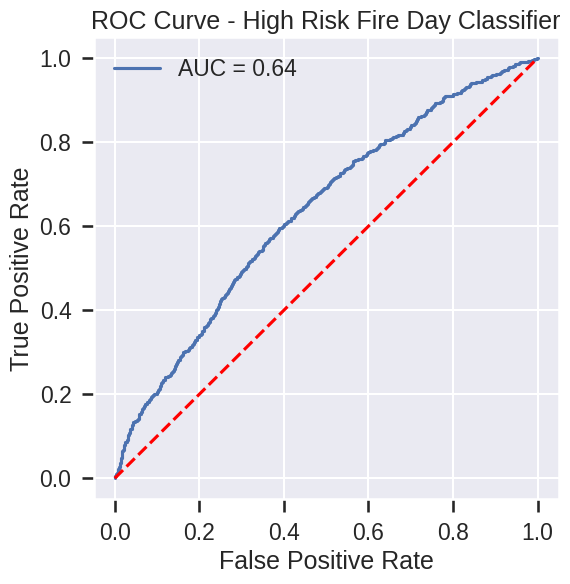

In [28]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

log_data['pred_prob'] = log_model.predict(X)
log_data['pred_class'] = (log_data['pred_prob'] >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, log_data['pred_class'])
print("Confusion Matrix:\n", cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y, log_data['pred_prob'])
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve - High Risk Fire Day Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [29]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prepare data
multi_data = df_daily.dropna()

X_multi = multi_data[['mean_temp', 'total_precip', 'mean_wind', 'mean_cloud']]
y_multi = multi_data['trash_fire_count']

X_multi = sm.add_constant(X_multi)

# Fit model
model_multi = sm.OLS(y_multi, X_multi).fit()
print(model_multi.summary())

# Predictions
y_pred_multi = model_multi.predict(X_multi)

# Model performance
rmse = np.sqrt(mean_squared_error(y_multi, y_pred_multi))
r2 = r2_score(y_multi, y_pred_multi)

print("Multi Linear Regression Performance:")
print("RMSE:", rmse)
print("R²:", r2)


                            OLS Regression Results                            
Dep. Variable:       trash_fire_count   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     48.56
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.34e-39
Time:                        02:52:04   Log-Likelihood:                -5834.2
No. Observations:                2454   AIC:                         1.168e+04
Df Residuals:                    2449   BIC:                         1.171e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.1520      0.209     29.404   

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

log_data = multi_data.copy()

# Predictors & target
X_log = log_data[['mean_temp', 'total_precip', 'mean_wind', 'mean_cloud']]
y_log = log_data['high_risk']

X_log = sm.add_constant(X_log)

# Fit logistic regression
log_model_multi = sm.Logit(y_log, X_log).fit()
print(log_model_multi.summary())

# Class predictions
log_data['pred_prob'] = log_model_multi.predict(X_log)
log_data['pred_class'] = (log_data['pred_prob'] >= 0.5).astype(int)

# Confusion Matrix + Metrics
cm = confusion_matrix(y_log, log_data['pred_class'])
acc = accuracy_score(y_log, log_data['pred_class'])
prec = precision_score(y_log, log_data['pred_class'])
rec = recall_score(y_log, log_data['pred_class'])

print("\nConfusion Matrix:\n", cm)
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")


Optimization terminated successfully.
         Current function value: 0.587088
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              high_risk   No. Observations:                 2454
Model:                          Logit   Df Residuals:                     2449
Method:                           MLE   Df Model:                            4
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                 0.03936
Time:                        02:52:17   Log-Likelihood:                -1440.7
converged:                       True   LL-Null:                       -1499.7
Covariance Type:            nonrobust   LLR p-value:                 1.393e-24
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.3758      0.173     -2.173      0.030      -0.715      -0.037
mean_temp       -0.0338

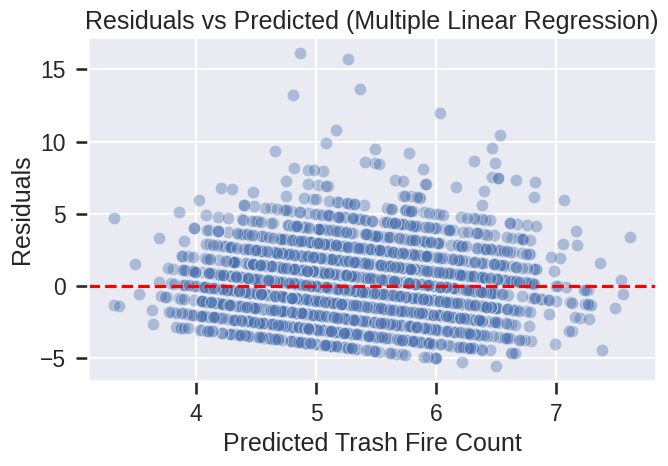

In [31]:
# Residual Plot
residuals = y_multi - y_pred_multi

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_multi, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted (Multiple Linear Regression)")
plt.xlabel("Predicted Trash Fire Count")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


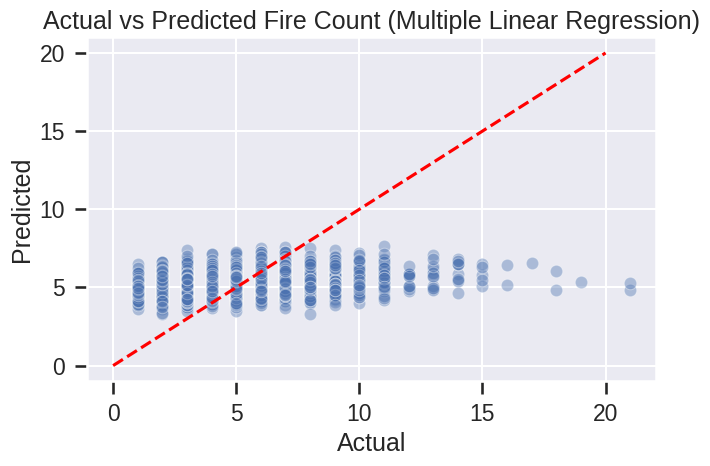

In [32]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_multi, y=y_pred_multi, alpha=0.4)
plt.plot([0,20], [0,20], 'r--')
plt.title("Actual vs Predicted Fire Count (Multiple Linear Regression)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


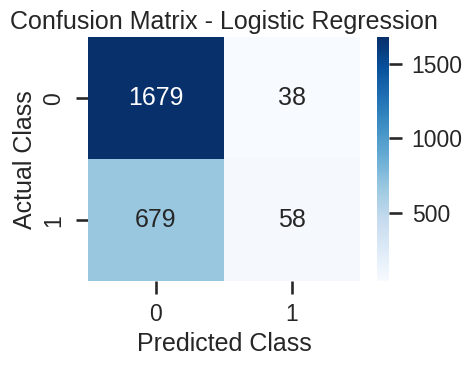

In [33]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


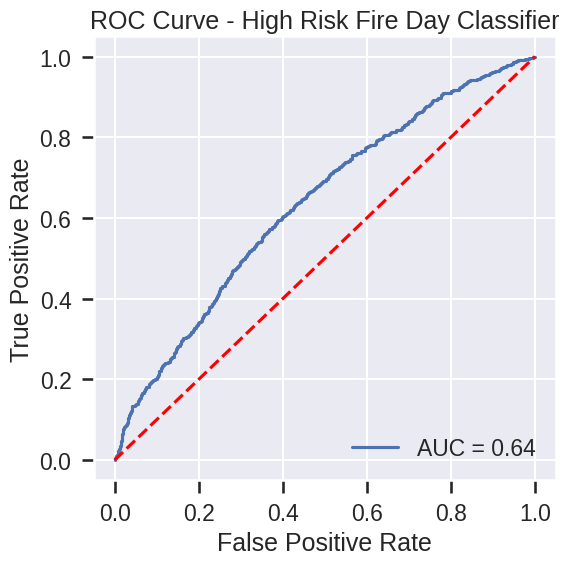

In [34]:
fpr, tpr, thresholds = roc_curve(y_log, log_data['pred_prob'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'r--')
plt.title("ROC Curve - High Risk Fire Day Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


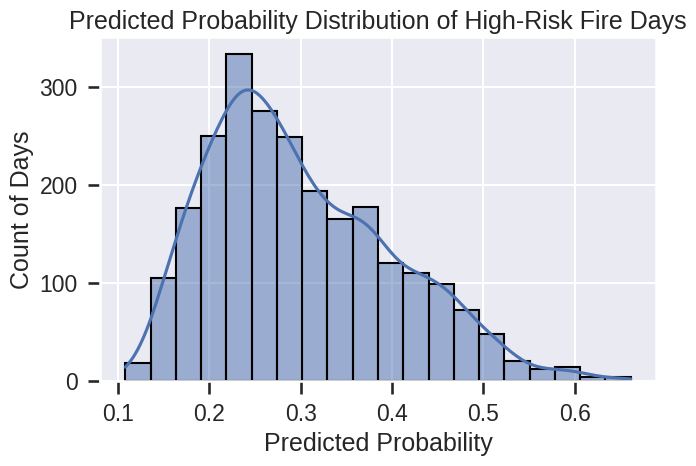

In [35]:
plt.figure(figsize=(7,5))
sns.histplot(log_data['pred_prob'], bins=20, kde=True)
plt.title("Predicted Probability Distribution of High-Risk Fire Days")
plt.xlabel("Predicted Probability")
plt.ylabel("Count of Days")
plt.tight_layout()
plt.show()


/tmp/ipython-input-337143590.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef, palette="viridis")


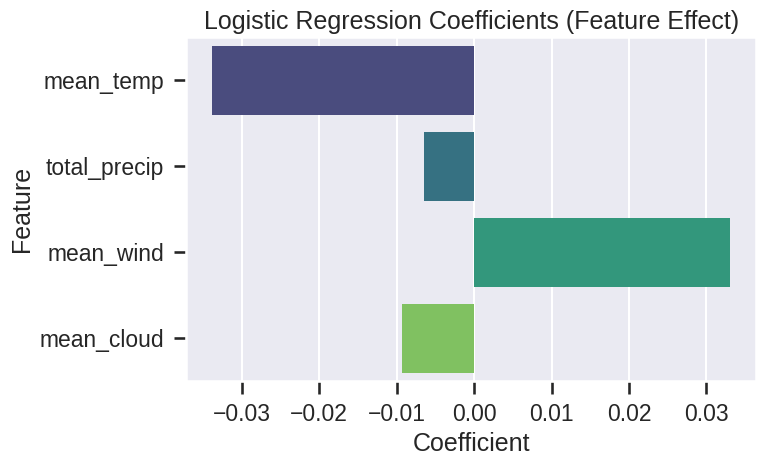

In [36]:
coef = pd.DataFrame({
    'Feature': ['mean_temp', 'total_precip', 'mean_wind', 'mean_cloud'],
    'Coefficient': log_model_multi.params[1:]
})

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coef, palette="viridis")
plt.title("Logistic Regression Coefficients (Feature Effect)")
plt.tight_layout()
plt.show()
